# Prac 06.1
Face detection using OpenCV Haar cascade detector.

### Step 0 - Imports

In [19]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1 - Load an image containing faces

(np.float64(-0.5), np.float64(663.5), np.float64(442.5), np.float64(-0.5))

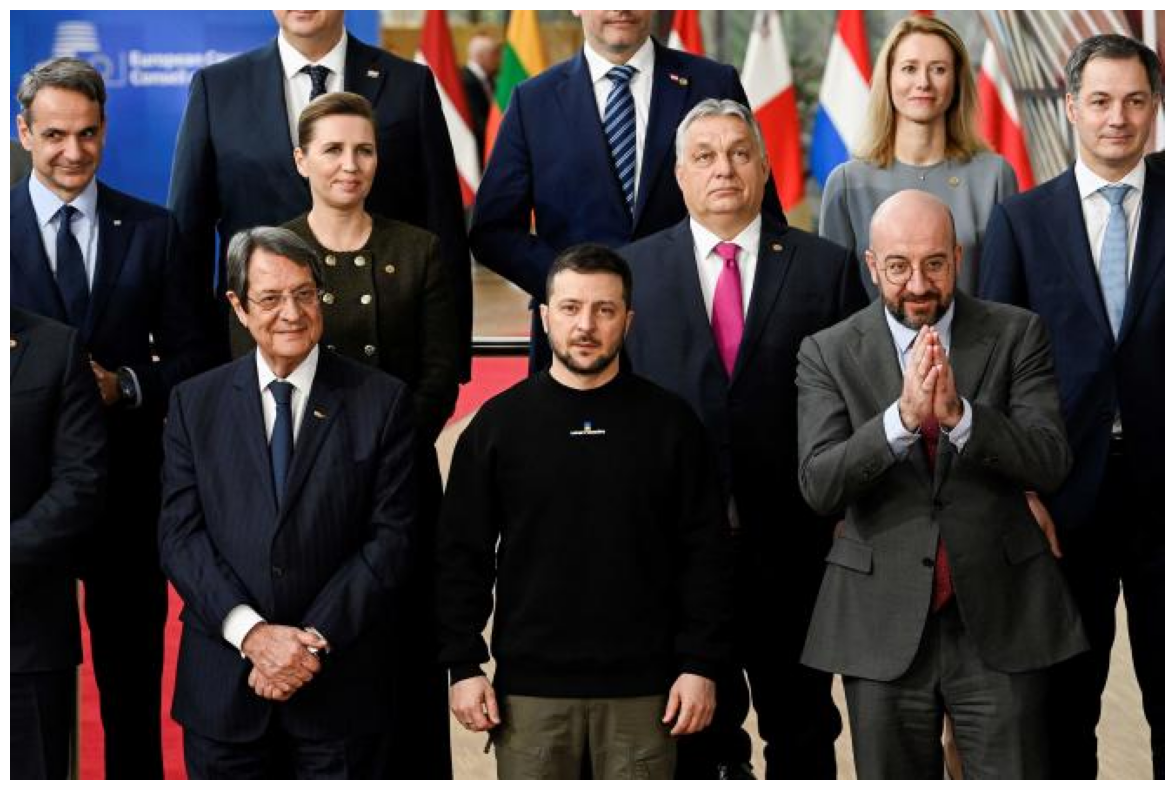

In [20]:
img = cv2.imread('../data/eu_summit.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

### Step 2 - Load the face detector (OpenCV Haar cascade)

In [21]:
# OpenCV ships with a pre-trained Haar cascade for frontal face detection
casc_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(casc_path)
print('Detector loaded:', not face_cascade.empty())

Detector loaded: True


### Step 3 - Run the detector on the image

In [22]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, flags=cv2.CASCADE_SCALE_IMAGE)
print(f'Faces detected: {len(faces)}')

Faces detected: 9


### Step 4 - Draw bounding boxes (different colour per face)

Text(0.5, 1.0, '9 faces detected')

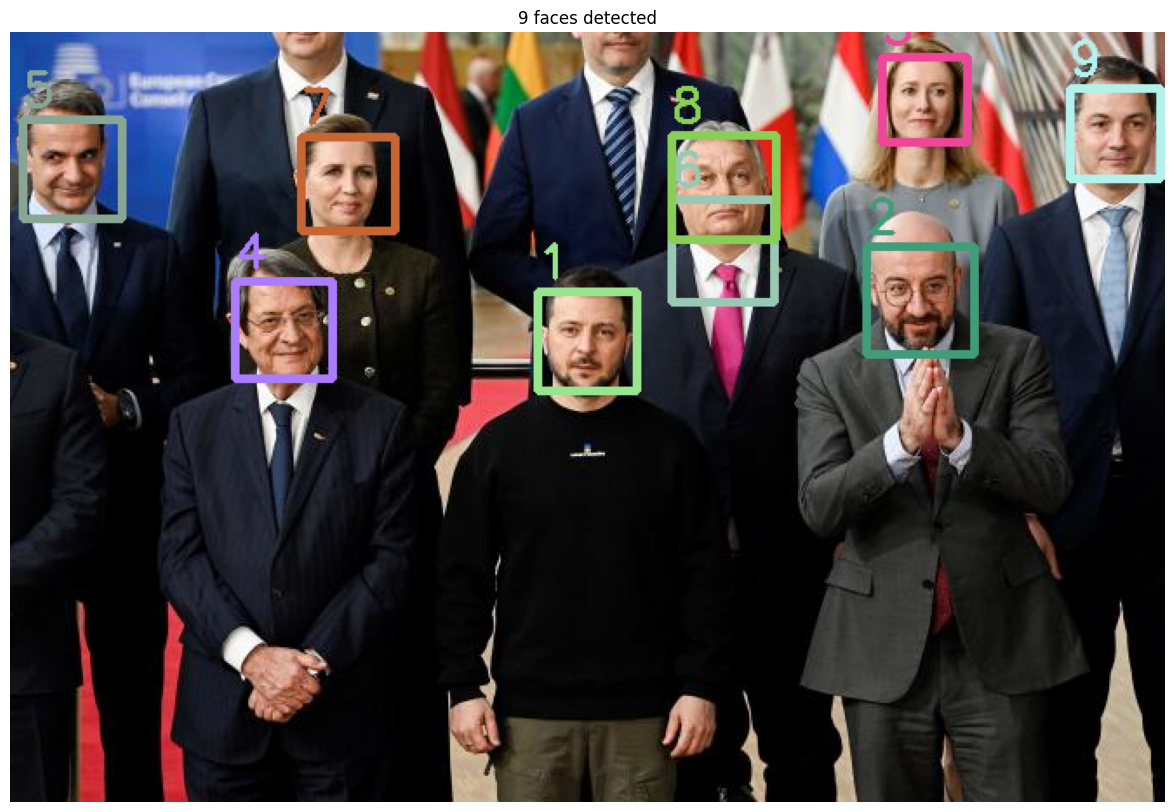

In [23]:
# Generate a distinct colour for each detected face
np.random.seed(42)
colors = [tuple(np.random.randint(50, 255, 3).tolist()) for _ in range(len(faces))]

result = np.copy(img)
for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(result, (x, y), (x+w, y+h), colors[i], 3)
    cv2.putText(result, str(i+1), (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.9, colors[i], 2)

plt.imshow(result)
plt.axis('off')
plt.title(f'{len(faces)} faces detected')

### Step 5 - More challenging image: crowd photo (img.png)

Faces detected in img.png: 81


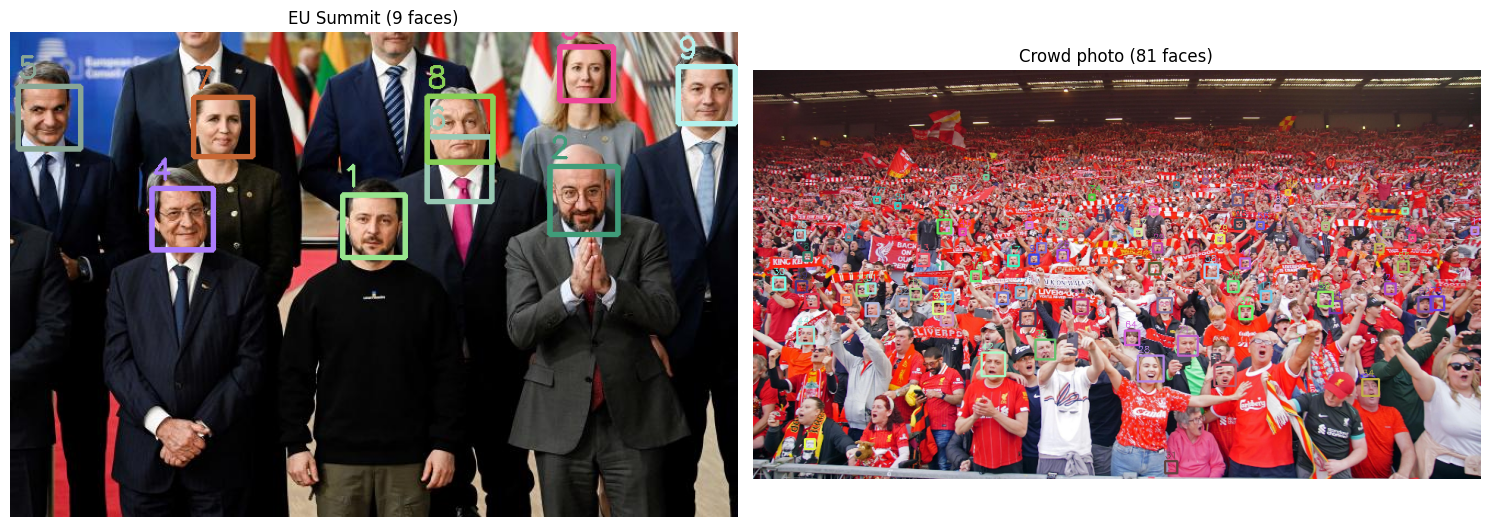

In [24]:
img2 = cv2.imread('../data/img.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

faces2 = face_cascade.detectMultiScale(gray2, scaleFactor=1.1, minNeighbors=5, flags=cv2.CASCADE_SCALE_IMAGE)
print(f'Faces detected in img.png: {len(faces2)}')

# Draw bounding boxes on a downscaled copy (img.png is 4K — scale down for display)
scale = 0.25
display2 = cv2.resize(img2, None, fx=scale, fy=scale)
result2 = display2.copy()
np.random.seed(7)
colors2 = [tuple(np.random.randint(50, 255, 3).tolist()) for _ in range(len(faces2))]
for i, (x, y, w, h) in enumerate(faces2):
    xs, ys, ws, hs = int(x*scale), int(y*scale), int(w*scale), int(h*scale)
    cv2.rectangle(result2, (xs, ys), (xs+ws, ys+hs), colors2[i], 2)
    cv2.putText(result2, str(i+1), (xs, max(ys-4, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, colors2[i], 1)

plt.subplot(121), plt.imshow(result),  plt.title(f'EU Summit ({len(faces)} faces)'),  plt.axis('off')
plt.subplot(122), plt.imshow(result2), plt.title(f'Crowd photo ({len(faces2)} faces)'), plt.axis('off')
plt.tight_layout()

**Observations:**
- The detector works well on frontal, well-lit faces at medium range (EU Summit: 9 faces).
- On the large crowd photo the detector finds **81 faces** with default settings — many more due to the sheer number of people.
- Many small or turned faces in the crowd are **missed** — the Haar cascade is optimised for frontal views.
- Some false positives appear on high-contrast non-face regions that share Haar feature patterns.
- Lowering `minNeighbors` increases recall (more faces found) but also raises false positives.